In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Charger les données
data = pd.read_csv('Salary_Data.csv')   # ⚠️ adapte si besoin
data

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [2]:
#  Variables
X = data[['YearsExperience']]   # une seule variable
y = data['Salary']

In [3]:
#  Train / Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=0
)

In [4]:

#  Transformation polynomiale
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)   # degré 2
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [5]:
#  Modèle
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
#  Coefficients
print("Intercept :", model.intercept_)
print("Coefficients :", model.coef_)


Intercept : 28150.604589132985
Coefficients : [   0.         8712.28148584   57.78239507]


In [7]:

#  Prédiction
y_pred = model.predict(X_test_poly)

In [8]:
#  Métriques
from sklearn import metrics

print('MAE :', metrics.mean_absolute_error(y_test, y_pred))
print('MSE :', metrics.mean_squared_error(y_test, y_pred))
print('RMSE :', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R² :', metrics.r2_score(y_test, y_pred))

MAE : 3562.939035525857
MSE : 21559299.688830055
RMSE : 4643.199294541432
R² : 0.9742792461789879


C:\Users\ossam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


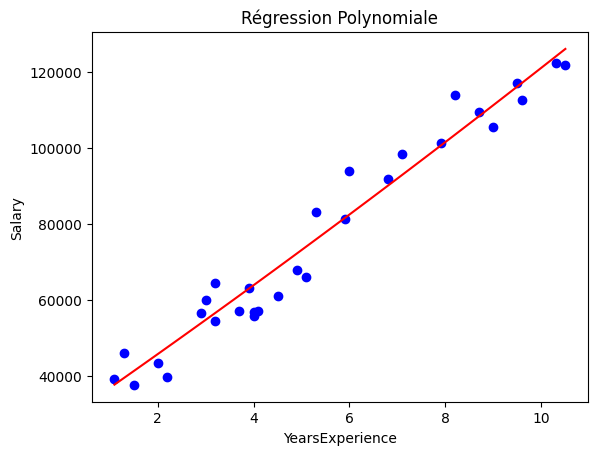

In [9]:

#  Visualisation (courbe lisse)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_range_poly = poly.transform(X_range)

plt.scatter(X, y, color='blue')
plt.plot(X_range, model.predict(X_range_poly), color='red')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Régression Polynomiale')
plt.show()

In [10]:

# Nouvelle prédiction
NewData = pd.DataFrame([[5],[4]], columns=['YearsExperience'])
NewData_poly = poly.transform(NewData)

y_new = model.predict(NewData_poly)
print("Nouvelles prédictions :", y_new)

Nouvelles prédictions : [73156.57189501 63924.24885357]
